<a href="https://colab.research.google.com/github/EstebanBotero03/Senalesysistemas/blob/main/TALLER_SYS_LAPLACE_PARTE_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TALLER LAPLACE PARTE 1 ESTEBAN BOTERO

# PUNTO 1

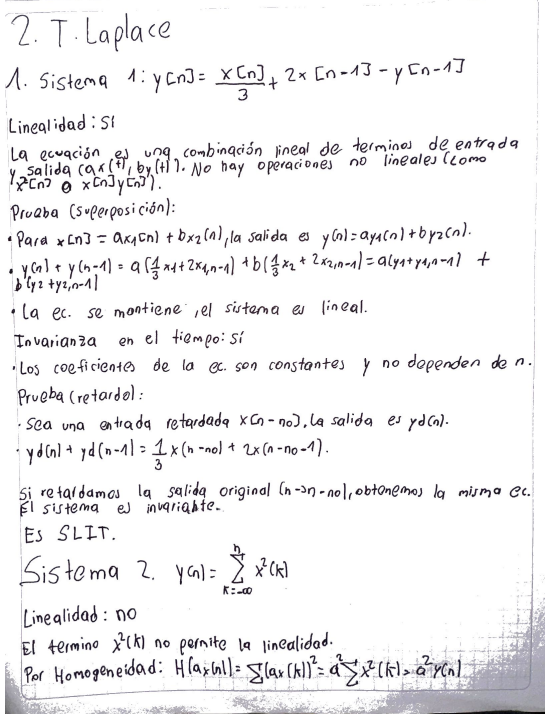

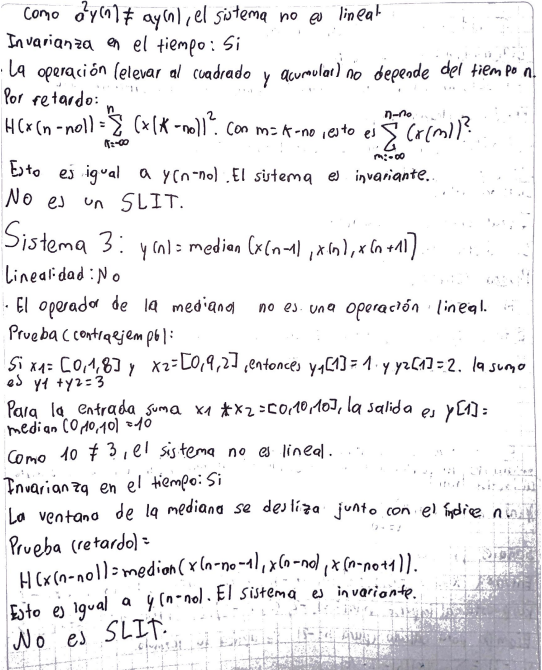

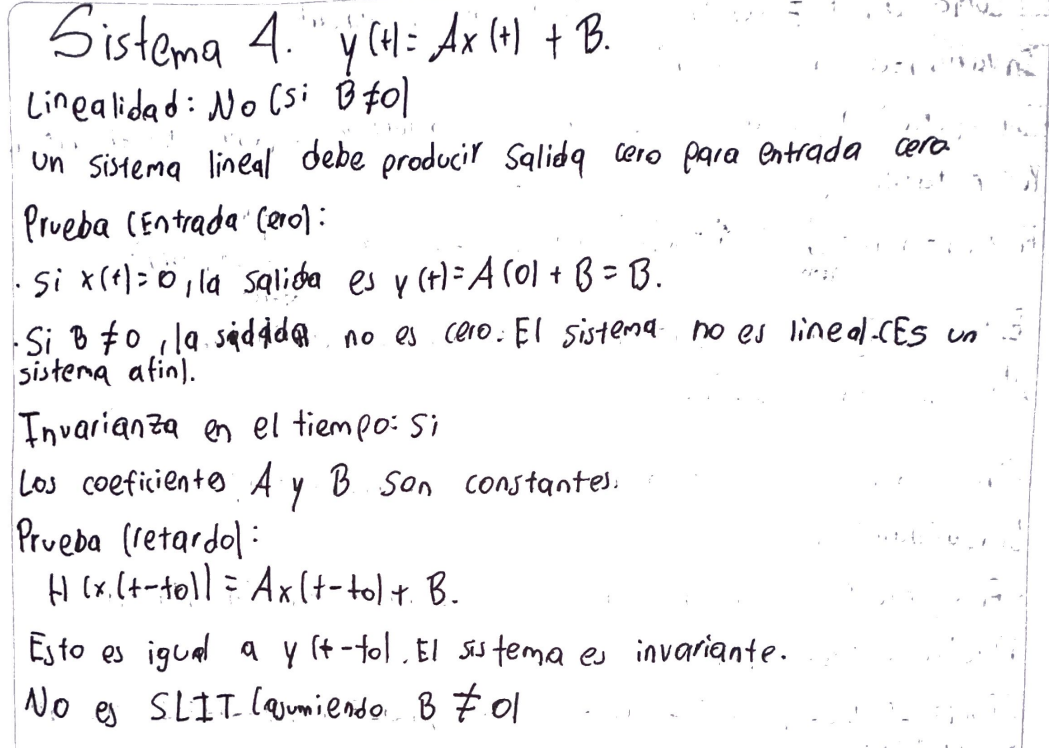

In [1]:
import numpy as np
from scipy.signal import lfilter
from scipy.ndimage import median_filter

# --- Configuración General para las Simulaciones ---
# Generar señales de entrada y constantes que se usarán en las pruebas.
np.random.seed(0) # Para resultados reproducibles
n_samples = 50
n_time_vector = np.arange(n_samples)
delay = 10 # Retardo para la prueba de invarianza en el tiempo

# Señales de entrada discretas (para sistemas 1, 2, 3)
x1_d = np.random.randn(n_samples)
x2_d = np.random.randn(n_samples)

# Señales de entrada continuas (simuladas discretamente para sistema 4)
t = np.linspace(0, 1, n_samples)
x1_c = np.sin(2 * np.pi * 5 * t)
x2_c = np.cos(2 * np.pi * 3 * t)

# Constantes para la prueba de linealidad
a, b = 2.5, -1.5

print("Iniciando simulación de sistemas...\n")

#==============================================================================
# 1. Sistema: y[n] = x[n]/3 + 2x[n-1] - y[n-1]
#==============================================================================
print("--- Sistema 1: y[n] = x[n]/3 + 2x[n-1] - y[n-1] ---")

# Reescribiendo: y[n] + y[n-1] = (1/3)x[n] + 2x[n-1]
b_coeffs = [1/3, 2]  # Coeficientes del lado de x
a_coeffs = [1, 1]    # Coeficientes del lado de y

def system1(x):
    return lfilter(b_coeffs, a_coeffs, x)

# 1.1 Prueba de Linealidad
y1 = system1(x1_d)
y2 = system1(x2_d)
y_superposition = a * y1 + b * y2

x_combined = a * x1_d + b * x2_d
y_combined = system1(x_combined)

if np.allclose(y_superposition, y_combined):
    print("Resultado de Linealidad: SÍ")
else:
    print("Resultado de Linealidad: NO")

# 1.2 Prueba de Invarianza en el Tiempo
x1_delayed = np.zeros_like(x1_d)
x1_delayed[delay:] = x1_d[:-delay]
y_from_delayed_input = system1(x1_delayed)

y1_original = system1(x1_d)
y_delayed_output = np.zeros_like(y1_original)
y_delayed_output[delay:] = y1_original[:-delay]

if np.allclose(y_from_delayed_input, y_delayed_output):
    print("Resultado de Invarianza en el Tiempo: SÍ")
else:
    print("Resultado de Invarianza en el Tiempo: NO")
print("Conclusión: El sistema ES un SLIT.\n")


#==============================================================================
# 2. Sistema: y[n] = Σ_{k=-∞ a n} x^2[k]
#==============================================================================
print("--- Sistema 2: y[n] = Σ x^2[k] ---")

def system2(x):
    return np.cumsum(x**2)

# 2.1 Prueba de Linealidad
y1 = system2(x1_d)
y2 = system2(x2_d)
y_superposition = a * y1 + b * y2

x_combined = a * x1_d + b * x2_d
y_combined = system2(x_combined)

if np.allclose(y_superposition, y_combined):
    print("Resultado de Linealidad: SÍ")
else:
    print("Resultado de Linealidad: NO")

# 2.2 Prueba de Invarianza en el Tiempo
x1_delayed = np.zeros_like(x1_d)
x1_delayed[delay:] = x1_d[:-delay]
y_from_delayed_input = system2(x1_delayed)

y1_original = system2(x1_d)
y_delayed_output = np.zeros_like(y1_original)
y_delayed_output[delay:] = y1_original[:-delay]

if np.allclose(y_from_delayed_input, y_delayed_output):
    print("Resultado de Invarianza en el Tiempo: SÍ")
else:
    print("Resultado de Invarianza en el Tiempo: NO")
print("Conclusión: El sistema NO es Lineal, pero SÍ es Invariante en el Tiempo.\n")


#==============================================================================
# 3. Sistema: y[n] = median(x[n]) con ventana de tamaño 3
#==============================================================================
print("--- Sistema 3: y[n] = median(x[n]) con ventana 3 ---")
window_size = 3

def system3(x):
    # Usamos modo 'constant' para manejar los bordes de forma predecible
    return median_filter(x, size=window_size, mode='constant')

# Para una prueba justa, ignoramos los bordes que son afectados por el filtro
start_index = delay + window_size
end_index = -window_size

# 3.1 Prueba de Linealidad
y1 = system3(x1_d)
y2 = system3(x2_d)
y_superposition = a * y1 + b * y2
x_combined = a * x1_d + b * x2_d
y_combined = system3(x_combined)

if np.allclose(y_superposition[start_index:end_index], y_combined[start_index:end_index]):
    print("Resultado de Linealidad: SÍ")
else:
    print("Resultado de Linealidad: NO")

# 3.2 Prueba de Invarianza en el Tiempo (ignorando bordes)
x1_delayed = np.zeros_like(x1_d)
x1_delayed[delay:] = x1_d[:-delay]
y_from_delayed_input = system3(x1_delayed)

y1_original = system3(x1_d)
y_delayed_output = np.zeros_like(y1_original)
y_delayed_output[delay:] = y1_original[:-delay]

if np.allclose(y_from_delayed_input[start_index:end_index], y_delayed_output[start_index:end_index]):
    print("Resultado de Invarianza en el Tiempo: SÍ (ignorando efectos de borde)")
else:
    print("Resultado de Invarianza en el Tiempo: NO")
print("Conclusión: El sistema NO es Lineal, pero SÍ es Invariante en el Tiempo.\n")


#==============================================================================
# 4. Sistema: y(t) = Ax(t) + B
#==============================================================================
print("--- Sistema 4: y(t) = Ax(t) + B ---")
A_param = 1.5
B_param = 4.0 # Offset que causa la no linealidad

def system4(x):
    return A_param * x + B_param

# 4.1 Prueba de Linealidad
y1 = system4(x1_c)
y2 = system4(x2_c)
y_superposition = a * y1 + b * y2
x_combined = a * x1_c + b * x2_c
y_combined = system4(x_combined)

if np.allclose(y_superposition, y_combined):
    print("Resultado de Linealidad: SÍ")
else:
    print("Resultado de Linealidad: NO")

# 4.2 Prueba de Invarianza en el Tiempo (corregida para offset)
x1_delayed = np.zeros_like(x1_c)
x1_delayed[delay:] = x1_c[:-delay]
y_from_delayed_input = system4(x1_delayed)

y1_original = system4(x1_c)
# La salida retardada debe rellenarse con el valor de offset B, no con 0
y_delayed_output = np.full_like(y1_original, fill_value=B_param)
y_delayed_output[delay:] = y1_original[:-delay]

if np.allclose(y_from_delayed_input, y_delayed_output):
    print("Resultado de Invarianza en el Tiempo: SÍ")
else:
    print("Resultado de Invarianza en el Tiempo: NO")
print("Conclusión: El sistema NO es Lineal (si B!=0), pero SÍ es Invariante en el Tiempo.\n")

Iniciando simulación de sistemas...

--- Sistema 1: y[n] = x[n]/3 + 2x[n-1] - y[n-1] ---
Resultado de Linealidad: SÍ
Resultado de Invarianza en el Tiempo: SÍ
Conclusión: El sistema ES un SLIT.

--- Sistema 2: y[n] = Σ x^2[k] ---
Resultado de Linealidad: NO
Resultado de Invarianza en el Tiempo: SÍ
Conclusión: El sistema NO es Lineal, pero SÍ es Invariante en el Tiempo.

--- Sistema 3: y[n] = median(x[n]) con ventana 3 ---
Resultado de Linealidad: NO
Resultado de Invarianza en el Tiempo: SÍ (ignorando efectos de borde)
Conclusión: El sistema NO es Lineal, pero SÍ es Invariante en el Tiempo.

--- Sistema 4: y(t) = Ax(t) + B ---
Resultado de Linealidad: SÍ
Resultado de Invarianza en el Tiempo: SÍ
Conclusión: El sistema NO es Lineal (si B!=0), pero SÍ es Invariante en el Tiempo.



# PUNTO 2

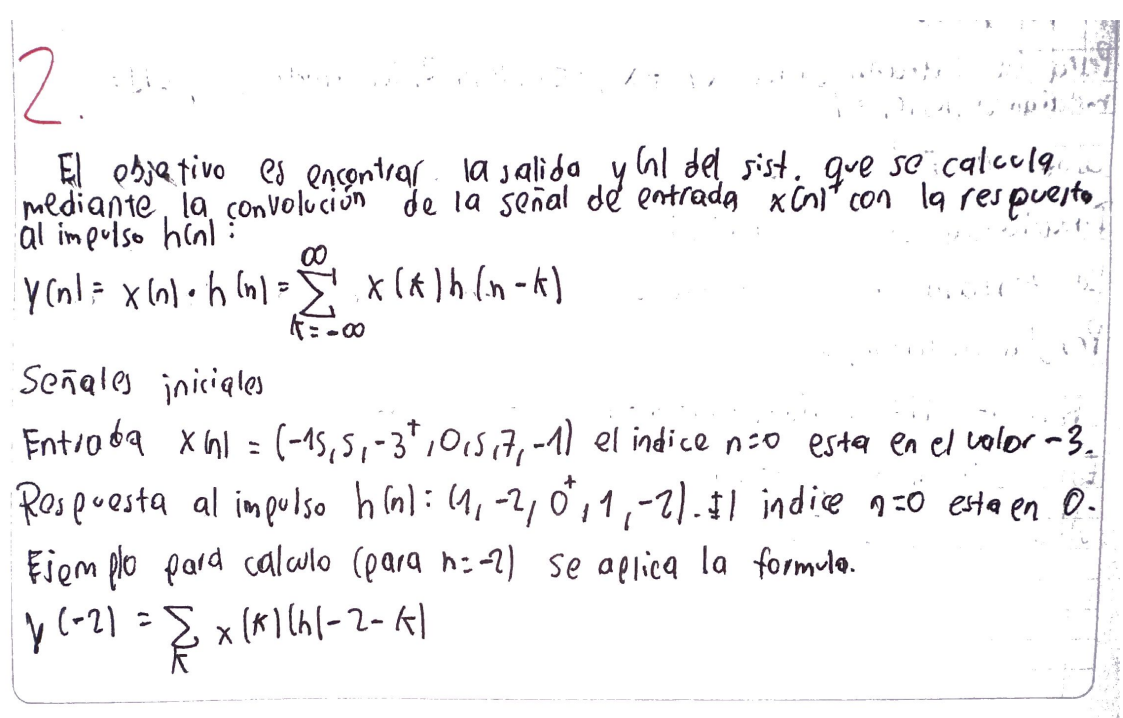

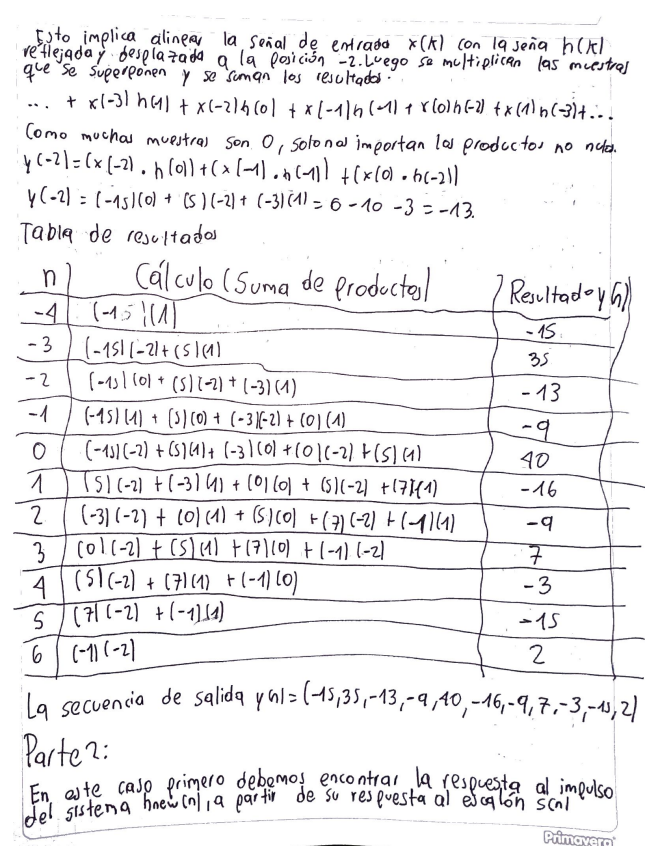

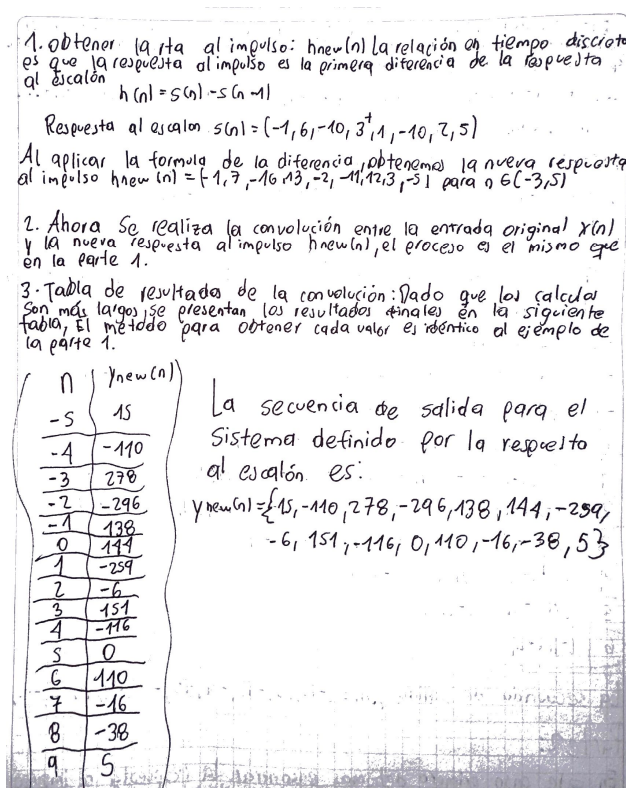

In [5]:
import numpy as np

# Definir las secuencias sin los índices de tiempo (solo los valores)
x = np.array([-15, 5, -3, 0, 5, 7, -1])
h = np.array([1, -2, 0, 1, -2])

# Calcular la convolución
y = np.convolve(x, h, mode='full')

print("La secuencia de salida y[n] es:")
print(y)
# Resultado: [-15  35 -13  -9  40 -16  -9   7  -3 -15   2]

La secuencia de salida y[n] es:
[-15  35 -13  -9  40 -16  -9   7  -3 -15   2]


In [6]:
import numpy as np

# Señal de entrada original
x = np.array([-15, 5, -3, 0, 5, 7, -1])

# Respuesta al escalón dada
# Nota: np.diff calcula s[i+1] - s[i]. Para obtener h[n] = s[n] - s[n-1],
# necesitamos añadir un 0 al inicio de s[n] para representar s[n-1]
# y que el primer valor sea s[-3]-s[-4] = -1-0.
s_vals = np.array([-1, 6, -10, 3, 1, -10, 2, 5])
# Asumimos que s[n] se mantiene en 5 y luego se apaga, lo que causa el h[5]=-5.
# Para el cálculo, se puede incluir el último punto para obtener la diferencia final.
# h_new = s[n] - s[n-1].
s_padded = np.concatenate(([0], s_vals, [5]))
h_new = np.diff(s_padded)

# También podemos definir h_new directamente desde nuestro cálculo manual
h_new_manual = np.array([-1, 7, -16, 13, -2, -11, 12, 3, -5])

# Calcular la convolución
y_new = np.convolve(x, h_new_manual, mode='full')

print("La nueva respuesta al impulso h_new[n] es:")
print(h_new_manual)
# Resultado: [-1   7 -16  13  -2 -11  12   3  -5]

print("\nLa nueva secuencia de salida y_new[n] es:")
print(y_new)
# Resultado:
# [  15.  -110.   278.  -299.   148.   149.  -266.    -1.    74.  -106.
#   -20.   113.     9.    -4.     5.]

La nueva respuesta al impulso h_new[n] es:
[ -1   7 -16  13  -2 -11  12   3  -5]

La nueva secuencia de salida y_new[n] es:
[  15 -110  278 -296  138  144 -259   -6  151 -116    0  110  -16  -38
    5]


# PUNTO 3

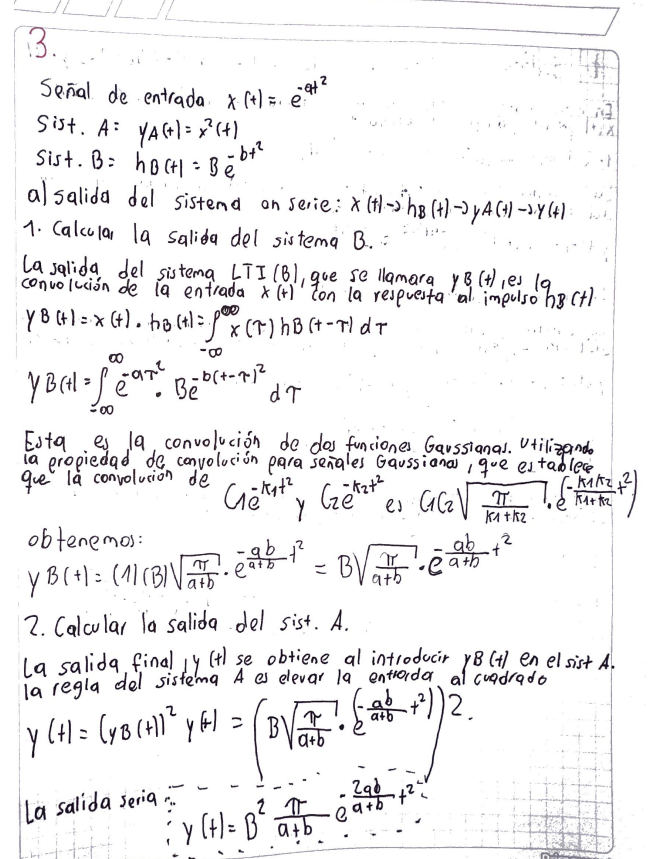

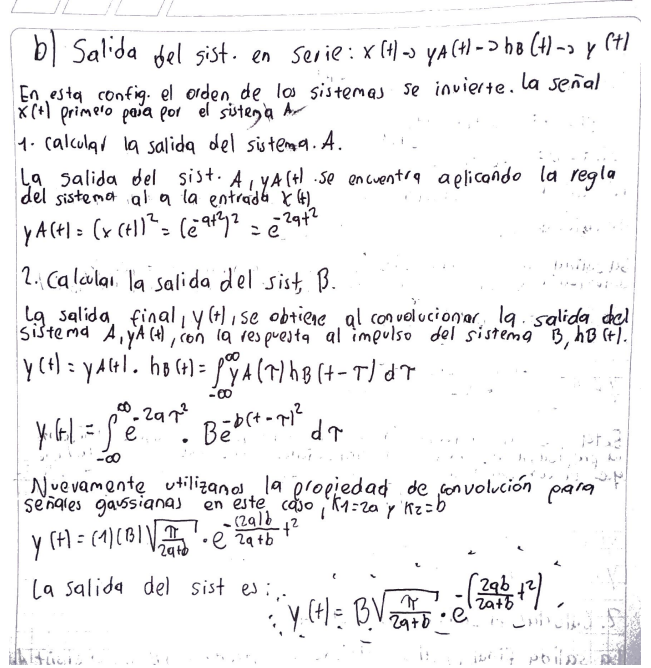